In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import jax.nn as jnn
from jax.random import PRNGKey
import optax
import gymnax
import matplotlib.pyplot as plt
from jax import vmap
from jax.flatten_util import ravel_pytree

import sys
sys.path.insert(0, "..")

from bayesoptax.loop import run, run_seeds
from bayesoptax.utils import Bounds

In [2]:
key = PRNGKey(42)
key, key_reset, key_policy, key_step = jr.split(key, 4)

env_name = "CartPole-v1"
env, env_params = gymnax.make(env_name)

action_list = jnp.array([0, 1.])
num_actions = len(action_list)

print(env_params)
ts = jnp.arange(0, env_params.tau * env_params.max_steps_in_episode, env_params.tau)

obs, state = env.reset(key_reset, env_params)
obs, state

EnvParams(max_steps_in_episode=500, gravity=9.8, masscart=1.0, masspole=0.1, total_mass=1.1, length=0.5, polemass_length=0.05, force_mag=10.0, tau=0.02, theta_threshold_radians=0.20943951023931953, x_threshold=2.4)


(Array([ 0.02276642,  0.02878675, -0.03183058, -0.02373698], dtype=float32),
 EnvState(time=Array(0, dtype=int32, weak_type=True), x=Array(0.02276642, dtype=float32), x_dot=Array(0.02878675, dtype=float32), theta=Array(-0.03183058, dtype=float32), theta_dot=Array(-0.02373698, dtype=float32)))

In [3]:
def linear_controller(obs_dim, num_actions, key, scale=1e-2):
    k1, k2 = jr.split(key)
    W = jr.normal(k1, (obs_dim, num_actions)) * scale
    b = jr.normal(k2, (num_actions,)) * scale
    return (W, b)

def policy(params, x):
    W, b = params
    logits = jnp.dot(x, W) + b
    return jax.nn.softmax(logits)

def get_action(params, x, key: PRNGKey):
    action_probabilities = policy(params, x)
    action_indices = jnp.arange(num_actions)
    sampled_action = jr.choice(key, action_indices, p=action_probabilities)
    return action_list[sampled_action], sampled_action

def get_log_prob(params, x, action_idx):
    action_probs = policy(params, x)
    p = action_probs[action_idx]
    return jnp.log(p)

In [4]:
key, subkey = jr.split(key)
params = linear_controller(env.obs_shape[0], num_actions, key=subkey)

In [5]:
def rollout(params, env_params, rng_input:PRNGKey, steps_in_episode:int):
    """Rollout a jitted gymnax episode with lax.scan."""
    # Reset the environment
    rng_reset, rng_episode = jr.split(rng_input)
    obs, state = env.reset(rng_reset, env_params)


    def policy_step(state_input, tmp):
        """lax.scan compatible step transition in jax env."""
        obs, state, rng, done = state_input
        rng, rng_action, rng_step = jr.split(rng, 3)
        action, action_idx = get_action(params, obs, rng_action)
        next_obs, next_state, reward, next_done, _ = env.step(
          rng_step, state, action, env_params
        )

        done = jnp.logical_or(done, next_done)
        reward = reward * (1.0 - done)

        next_obs = jnp.where(done, obs, next_obs)
        next_state = jax.tree.map(lambda x, y: jnp.where(done, x, y), state, next_state)

        carry = [next_obs, next_state, rng, done]
        return carry, [obs, state, action, action_idx, reward, next_obs, done]

    # Scan over episode step loop
    _, scan_out = jax.lax.scan(
      policy_step,
      [obs, state, rng_episode, False],
      (),
      length=steps_in_episode, 
    )
    return scan_out

# Jit-Compiled Episode Rollout
jit_rollout = jax.jit(rollout, static_argnums=3)

def visualize_trajectory(params, key):
    obs, state, action, action_idx, reward, next_obs, done = rollout(
        params, env_params, rng_input=key, steps_in_episode=env_params.max_steps_in_episode
    )
    
    # Create time array
    ts = jnp.arange(0, env_params.tau * env_params.max_steps_in_episode, env_params.tau)
    
    fig, ax = plt.subplots(5,1,figsize=(8,8))
    
    ax[0].plot(ts, obs[:,0], color='C0')
    ax[0].set_title('Cart Position')
    
    ax[1].plot(ts, obs[:,1], color='C0')
    ax[1].set_title('Cart Velocity')
    
    ax[2].plot(ts, obs[:,2], color='C0')
    ax[2].set_title('Pole Angle')
    
    ax[3].plot(ts, action, color='C1')
    ax[3].set_title('Action')
    
    ax[4].plot(ts, reward, color='C2')
    ax[4].set_title('Reward')
    
    plt.tight_layout()
    plt.show()

Caption 1: Single rollout using the policy network without training


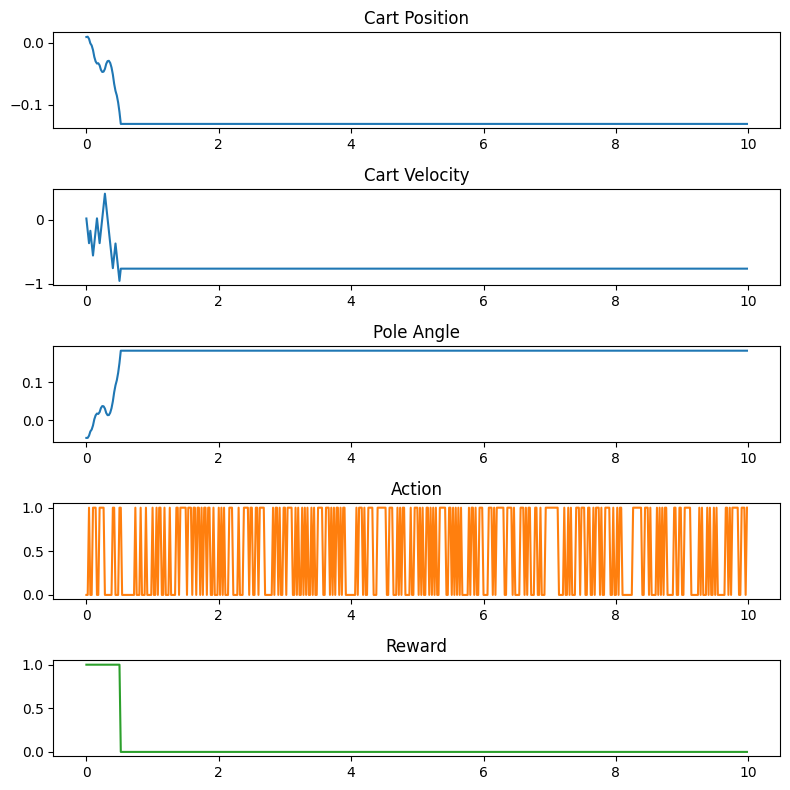

In [6]:
key, subkey = jr.split(key)
print('Caption 1: Single rollout using the policy network without training')
visualize_trajectory(params,key = subkey)

In [ ]:
flattened_params, unflatten = ravel_pytree(params)

def objective(theta):
    global key
    key, subkey = jr.split(key)
    obs, state, action, action_idx, reward, next_obs, done = jit_rollout(
        unflatten(theta), env_params, subkey, steps_in_episode=env_params.max_steps_in_episode
    )
    return -jnp.sum(reward)

dims = flattened_params.shape[0]
bounds = Bounds.uniform(-5, 5, D=dims)

results = run_seeds(
    objective=objective,
    bounds=bounds,
    n_init=5*dims,
    n_seeds=20,
    n_iter=100,
    kernel_name="matern52",
    acquisition_name="ts"
)

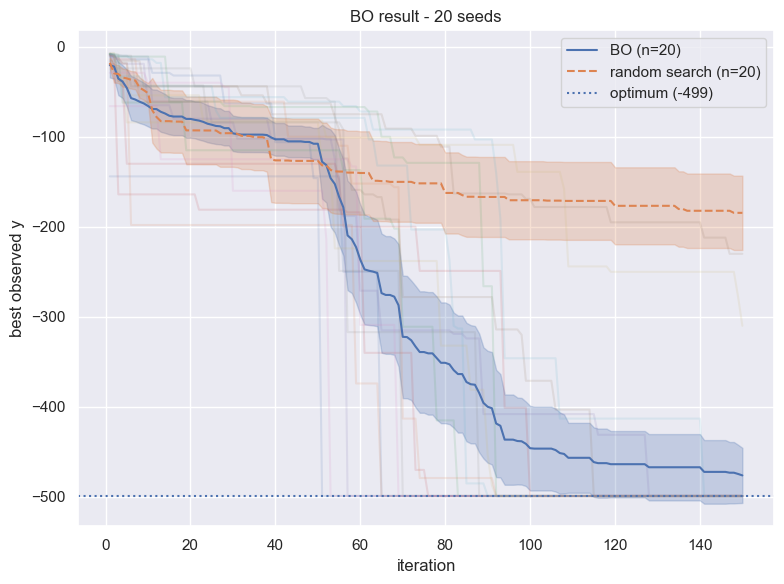

In [9]:
results.plot(true_optimum=-499)

Caption 2: Single rollout using the best params found by BO


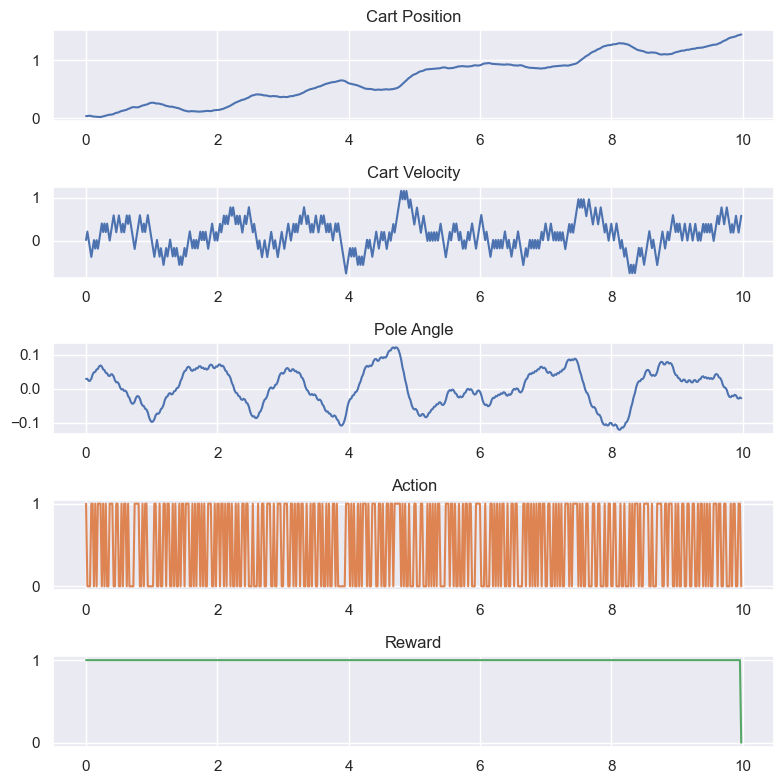

In [15]:
key, subkey = jr.split(key)
print('Caption 2: Single rollout using the best params found by BO')
best_params = unflatten(results.best_xs[0])
visualize_trajectory(best_params,key = subkey)

In [16]:
@jax.jit
def update_delta(delta, grad_theta):
    updated_delta = jax.tree.map(lambda x, y: x + y, delta, grad_theta)
    return updated_delta, None


def loss_REINFORCE(params, obs, action_idx, reward, baseline, gamma: float = 0.99):

    def trajectory_gradients(reward, obs, action_idx, baseline, delta):
        G_init = 0

        def step(carry, variables):
            G, delta = carry
            r, o, a_idx, b = variables

            G = gamma * G + r
            A_hat = G - b

            def loss_fn(params):
                return -get_log_prob(params, o, a_idx).squeeze()

            grad_delta = jax.grad(loss_fn)(params)
            grad_delta = jax.tree.map(lambda gd: gd * A_hat, grad_delta)
            delta, _ = update_delta(delta, grad_delta)
            return (G, delta), G

        variables = (reward[::-1], obs[::-1], action_idx[::-1], baseline[::-1])
        (_, delta), Gt = jax.lax.scan(step, (G_init, delta), variables)
        return delta, Gt

    parallel_traj = jax.vmap(trajectory_gradients, in_axes=(0, 0, 0, None, None))
    delta = jax.tree.map(lambda t: jnp.zeros(t.shape), params)
    deltas, Gs = parallel_traj(reward, obs, action_idx, baseline, delta)
    delta, _ = jax.lax.scan(update_delta, delta, deltas)
    return delta, Gs

loss_REINFORCE = jax.jit(loss_REINFORCE)

In [17]:
num_iters_pg = 1_000
n_batches_pg = 32
lr_pg = 0.005
gamma_pg = 0.99

key, subkey = jr.split(key)
params_pg = linear_controller(env.obs_shape[0], num_actions, key=subkey)

optim_pg  = optax.adam(learning_rate=lr_pg)
opt_state_pg = optim_pg.init(params_pg)

In [18]:
def pg_step(carry, iter_key):
    params, opt_state = carry

    keys = jr.split(iter_key, n_batches_pg)
    batch_rollout = jax.vmap(rollout, in_axes=(None, None, 0, None))
    obs_b, _, _, action_idx_b, reward_b, _, _ = batch_rollout(
        params, env_params, keys, env_params.max_steps_in_episode
    )

    baseline = jnp.zeros((env_params.max_steps_in_episode,))

    delta, _ = loss_REINFORCE(params, obs_b, action_idx_b, reward_b, baseline, gamma_pg)
    updates, opt_state = optim_pg.update(delta, opt_state, params)
    params = optax.apply_updates(params, updates)

    mean_return = jnp.mean(jnp.sum(reward_b, axis=-1))
    return (params, opt_state), mean_return


key, subkey = jr.split(key)
iter_keys_pg = jr.split(subkey, num_iters_pg)

(params_pg, _), history_pg = jax.lax.scan(pg_step, (params_pg, opt_state_pg), iter_keys_pg)

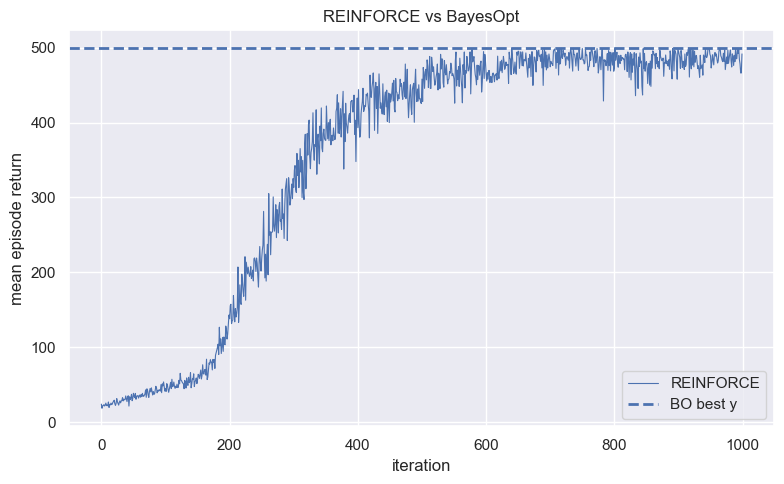

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_pg, linewidth=0.8, label='REINFORCE')
ax.axhline(y=float(499), color='C0', linestyle='--', linewidth=2, label='BO best y')
ax.set_xlabel('iteration')
ax.set_ylabel('mean episode return')
ax.set_title('REINFORCE vs BayesOpt')
ax.legend()
plt.tight_layout()
plt.show()

Caption 3: Single rollout using the best REINFORCE policy


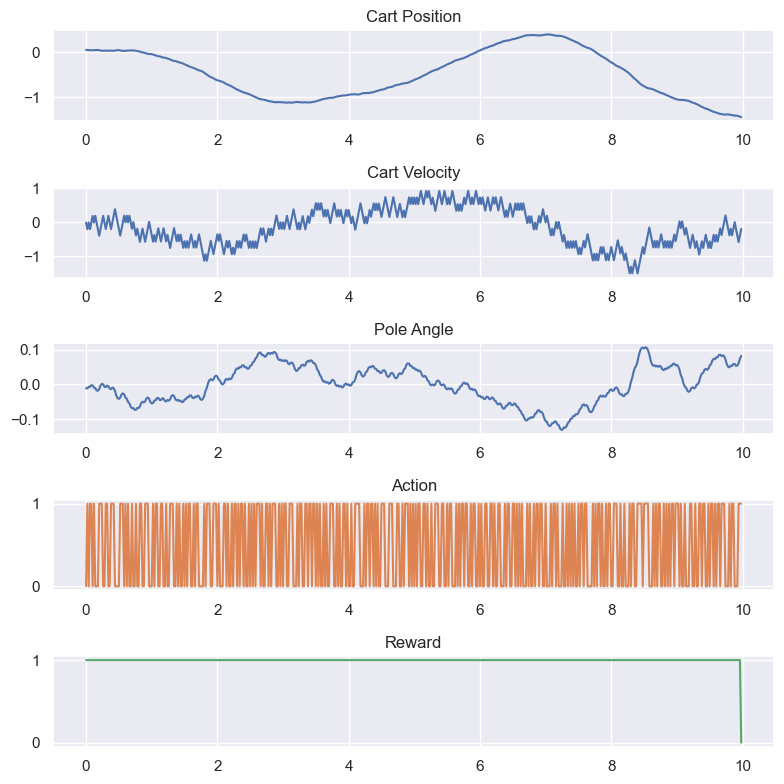

In [23]:
key, subkey = jr.split(key)
print('Caption 3: Single rollout using the best REINFORCE policy')
visualize_trajectory(params_pg, key=subkey)